In [1]:
from PIL import Image, ImageOps, ImageFont
import matplotlib.pyplot as plt
from modules.img_processing import DITHER_MODES, preprocess_img
from modules.palette_generator import get_asciis, make_symbol2value_map, \
    make_1d_bin_palette, make_2d_bin_palette, add_ansi_256_colors_grayscale
from modules.print_gallery import print_gallery
from modules.img2chars_mono_1d import img2char_arr_1d
from modules.img2chars_mono_2d import img2char_arr_2d
from modules.img2chars_mono_nd import img2char_arr_nd

In [2]:
ASCII_SET = add_ansi_256_colors_grayscale(get_asciis(), 4)
FONT = ImageFont.truetype("../fonts/CascadiaMono.ttf", 11)
IMG_PATH = "../imgs/irad_grad.bmp"
IMG_SIZE = (64, 64)

In [3]:
img = Image.open(IMG_PATH).convert("L")
img.thumbnail(IMG_SIZE)

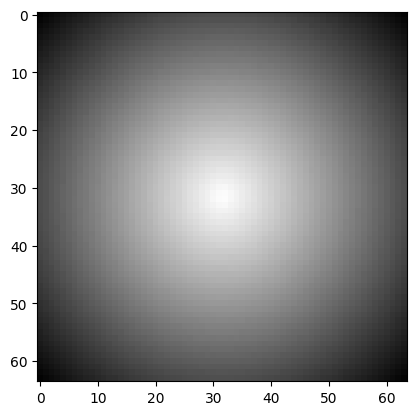

In [4]:
plt.imshow(img, cmap='gray', vmin=0, vmax=255, interpolation='none')

In [5]:
results = []

bins = 12
palette, palette_brs = make_1d_bin_palette(
    symbols=ASCII_SET,
    font=FONT,
    bins=bins,
    normalize=True)

results.append(img2char_arr_1d(
    img=ImageOps.scale(img, 0.5),
    bin_palette=palette,
    bin_vals=palette_brs))

bins = (9, 9)
palette, palette_brs = make_2d_bin_palette(
    symbols=ASCII_SET,
    font=FONT,
    bins=bins,
    normalize=True)
results.append(img2char_arr_2d(ImageOps.scale(img, 0.5), palette))

val_shape = (4, 2)
symbol2brightness = make_symbol2value_map(
    symbols=ASCII_SET,
    font=FONT,
    val_height=val_shape[0],
    val_width=val_shape[1],
    normalize=True)
results.append(img2char_arr_nd(
    img=img,
    symbol2brightness=symbol2brightness,
    win_shape=val_shape))

print_gallery(results, 3)

------------------------------------------------------------------------------------------------------------
 | }l]x&$Kw`V,CQ}MNg>v:{^[}ENk[ou\o | l~v21Hd6$R'z;+,,,~;~Bx.'EA09$ygj | ;;Q}}@PTT'`,,,,;;,,,,''TT7Q@[Q[; | 
 | <I6K0x?!1idoL]Q$3Bk+s}[ll7~QqS2s | e93KHFZ@-cj{]KrEb[B/7qi-nz wBrzn | Q}@@[T`,;;;ygQQQQQggy;;;,'TTQ@[Q | 
 | 9PEa,I=CEDHyOL9hvzT6dhWch\ j36GB | S5He._r}]6&DAP6$D@SdW&qC}j~.kq9M | }@[T ,|;QQ}}}}}}}}}}}}[Qy[,`TTQ@ | 
 | ZAra/|O3##uUOL_-]^ KGQi@&Bsj)'w& | O.T0Cwz&]0CT7/1+9;L?TH#5ALT)+hE[ | Q}`,|{Q}}}}PTTTTTTTTP|}}[Q[[,'TQ | 
 | #JV^3#p\$1ye;_8g?3y`+)I[L2b=)~xY | V<~(%H4WMV:C_--xd,-,8-+?N&Hcd-XV | [ ;|Q}}[[[T',,;;;;,,'TT|}}[Q[,:T | 
 | `rswkb]to<ff(k%w05WH3U.]{oMy=4W7 | '~dfK&C7H]-1h099MPJ+~,%_[]U4ZJ!0 | :,|Q}[[[[ ,;}QQQQQyy;,'T}|}[Q[,: | 
 | V<"7kqp~"{28Rm$8sWAN7Fg!+89B5tY? | ,3f<ESM]9]Tl9E%Z3{EH%B&"#,08QR=3 |  |{Q}[[[ ;{QQ[[}T}|QQ[; |{}[[[;  | 
 | ,aGDhIm ]TGG*a_3{uzSR$oTaYd7h,On | .QyfPP^{-tsd|T5X{mtFr1H;lb0#0<S: |  |{}[[[;.|QQ[[[TTT|}QQ[.:{|}[[[  | 
 | c=uWS@c(F[UM$Fn'

In [6]:
results = []

val_shape = (4, 2)
symbol2brightness = make_symbol2value_map(
    symbols=ASCII_SET,
    font=FONT,
    val_height=val_shape[0],
    val_width=val_shape[1],
    normalize=True)
results.append(img2char_arr_nd(
    img=img,
    symbol2brightness=symbol2brightness,
    win_shape=val_shape))

prep_img = preprocess_img(
    img=img,
    quantize_colors=4,
    dither=DITHER_MODES.BAYER)
results.append(img2char_arr_nd(
    img=prep_img,
    symbol2brightness=symbol2brightness,
    win_shape=val_shape))

prep_img = preprocess_img(
    img=img,
    quantize_colors=4,
    dither=DITHER_MODES.JJN)
results.append(img2char_arr_nd(
    img=prep_img,
    symbol2brightness=symbol2brightness,
    win_shape=val_shape))

print_gallery(results, 3)

------------------------------------------------------------------------------------------------------------
 | ;;Q}}@PTT'`,,,,;;,,,,''TT7Q@[Q[; |     -IjSMjZjZj;;;j;jZjZZjSyI     |  _-,q)ITj[;t;;;;;;;;;;QTjrp)q-,  | 
 | Q}@@[T`,;;;ygQQQQQggy;;;,'TTQ@[Q |   -IjjZj;;;;&I&I&I&;&;;;ZjZSyI   |  ?{{Ll;;;;;,,y\Ly\,[;,;;;;S?Z\(L | 
 | }@[T ,|;QQ}}}}}}}}}}}}[Qy[,`TTQ@ | -IjjZj;;&IjSjSZZZSZSjjy&;;;jSSyT | ){tS;;;;y/"S7;E@/[){Z[r\;;;Tt3Ql | 
 | Q}`,|{Q}}}}PTTTTTTTTP|}}[Q[[,'TQ | jSZj;;&IjFZFFF`````FZFZSyI;;;jSS | {TL;;;)QTLS[t)`_`t\TQ\"\Qa,;T?iZ | 
 | [ ;|Q}}[[[T',,;;;;,,'TT|}}[Q[,:T | jjj;&IjFZF`.a$y[y$i.`.`FSSyT;jZS | Ft;;&Qp/l(-.........LT_gQp/_;;?L | 
 | :,|Q}[[[[ ,;}QQQQQyy;,'T}|}[Q[,: | Zj;TISZF`.i$[ZZFZZZZy$..Z[jS&;;j | t;;_F\QZ_`.._gt]QNyi...?-{&[L;;T | 
 |  |{Q}[[[ ;{QQ[[}T}|QQ[; |{}[[[;  | Zj&Ij[FLa$[FZFl l lFZZy.`FZS&;;j | ;;;QQ)lQ...[/)/y[T)\Q..T`[%/(y;; | 
 |  |{}[[[;.|QQ[[[TTT|}QQ[.:{|}[[[  | jL&IjFF.i$[FF       ZZ[T.LZSjT;j | ;;;)]Q\...\QJ_\-T[\[(}...(\Ey?;; | 
 |  |Q}[[[;:|QQ[[[;

In [7]:
results = []

resized_img = Image.open(IMG_PATH).convert("L")
resized_img.thumbnail((IMG_SIZE[0] // 2, IMG_SIZE[1] // 2))
val_shape = (2, 1)
symbol2brightness = make_symbol2value_map(
    symbols=ASCII_SET,
    font=FONT,
    val_height=val_shape[0],
    val_width=val_shape[1],
    normalize=True)
results.append(img2char_arr_nd(
    img=resized_img,
    symbol2brightness=symbol2brightness,
    win_shape=val_shape))

resized_img = Image.open(IMG_PATH).convert("L")
resized_img.thumbnail(IMG_SIZE)
val_shape = (4, 2)
symbol2brightness = make_symbol2value_map(
    symbols=ASCII_SET,
    font=FONT,
    val_height=val_shape[0],
    val_width=val_shape[1],
    normalize=True)
results.append(img2char_arr_nd(
    img=resized_img,
    symbol2brightness=symbol2brightness,
    win_shape=val_shape))

resized_img = Image.open(IMG_PATH).convert("L")
resized_img.thumbnail((int(IMG_SIZE[0] * 1.5), int(IMG_SIZE[1] * 1.5)))
val_shape = (6, 3)
symbol2brightness = make_symbol2value_map(
    symbols=ASCII_SET,
    font=FONT,
    val_height=val_shape[0],
    val_width=val_shape[1],
    normalize=True)
results.append(img2char_arr_nd(
    img=resized_img,
    symbol2brightness=symbol2brightness,
    win_shape=val_shape))

resized_img = Image.open(IMG_PATH).convert("L")
resized_img.thumbnail((IMG_SIZE[0] * 2, IMG_SIZE[1] * 2))
val_shape = (8, 4)
symbol2brightness = make_symbol2value_map(
    symbols=ASCII_SET,
    font=FONT,
    val_height=val_shape[0],
    val_width=val_shape[1],
    normalize=True)
results.append(img2char_arr_nd(
    img=resized_img,
    symbol2brightness=symbol2brightness,
    win_shape=val_shape))

print_gallery(results, 4)


-----------------------------------------------------------------------------------------------------------------------------------------------
 | ;Qfd{46M7"'.,--,,+-,.'"T564WHJQ; | ;;Q}}@PTT'`,,,,;;,,,,''TT7Q@[Q[; | _jQQQQOC``  ..,,,,..  `"]DQQQQ], |  jQQ@0?""              ""?0@QQ,  | 
 | fdWUMT^.+omWznnkknnzWpo+,'TMbWHJ | Q}@@[T`,;;;ygQQQQQggy;;;,'TTQ@[Q | QQQQC`  .,]QQQQQQQQQQL,,  "]QQQQ | QQ@D"    ,,jjjQQQQjj,,,   ""0@QQ | 
 | {4MT',sGf4HQWMPPPPMMQHAnWo-'TMU[ | }@[T ,|;QQ}}}}}}}}}}}}[Qy[,`TTQ@ | QQC` ._]QQQQQQQQQQQQQQQQ]L. `]QQ | @0"   ,,jQQQ@@0000@@@QQj,,   "0@ | 
 | K5!.xQnHWP5YM777T77MY5PWH2Wn,'5K | Q}`,|{Q}}}}PTTTTTTTTP|}}[Q[[,'TQ | QC  _]QQQQQCCC"^^^"]DQQQQQ],  ]Q | D"   jQQ@@0?""""""""?00@QQ,   "3 | 
 | 5';21b$93MT`'-++++-,'TPtP@6{A~'3 | [ ;|Q}}[[[T',,;;;;,,'TT|}}[Q[,:T | C  ]QQQQQC`  .,,,,.  `]QQQQQL. ] | "  ~jQ@Q?"            "?Q@Ql,  " | 
 | !.21K@5MY',xGBB99BBGs,'YM5@K{2;! | :,|Q}[[[[ ,;}QQQQQyy;,'T}|}[Q[,: |   ]QQQQC` ._]QQQQQQ],. ^]QQQQL   |   ~jQ@0"    ,jQQQQj,,   "Q@Q

In [8]:
results = []

resized_img = Image.open(IMG_PATH).convert("L")
resized_img.thumbnail((IMG_SIZE[0] // 2, IMG_SIZE[1] // 2))
val_shape = (2, 1)
symbol2brightness = make_symbol2value_map(
    symbols=ASCII_SET,
    font=FONT,
    val_height=val_shape[0],
    val_width=val_shape[1],
    normalize=True)
results.append(img2char_arr_nd(
    img=preprocess_img(
        img=resized_img,
        quantize_colors=3,
        dither=DITHER_MODES.FS),
    symbol2brightness=symbol2brightness,
    win_shape=val_shape))

resized_img = Image.open(IMG_PATH).convert("L")
resized_img.thumbnail(IMG_SIZE)
val_shape = (4, 2)
symbol2brightness = make_symbol2value_map(
    symbols=ASCII_SET,
    font=FONT,
    val_height=val_shape[0],
    val_width=val_shape[1],
    normalize=True)
results.append(img2char_arr_nd(
    img=preprocess_img(
        img=resized_img,
        quantize_colors=3,
        dither=DITHER_MODES.FS),
    symbol2brightness=symbol2brightness,
    win_shape=val_shape))

resized_img = Image.open(IMG_PATH).convert("L")
resized_img.thumbnail((int(IMG_SIZE[0] * 1.5), int(IMG_SIZE[1] * 1.5)))
val_shape = (6, 3)
symbol2brightness = make_symbol2value_map(
    symbols=ASCII_SET,
    font=FONT,
    val_height=val_shape[0],
    val_width=val_shape[1],
    normalize=True)
results.append(img2char_arr_nd(
    img=preprocess_img(
        img=resized_img,
        quantize_colors=3,
        dither=DITHER_MODES.FS),
    symbol2brightness=symbol2brightness,
    win_shape=val_shape))

resized_img = Image.open(IMG_PATH).convert("L")
resized_img.thumbnail((IMG_SIZE[0] * 2, IMG_SIZE[1] * 2))
val_shape = (8, 4)
symbol2brightness = make_symbol2value_map(
    symbols=ASCII_SET,
    font=FONT,
    val_height=val_shape[0],
    val_width=val_shape[1],
    normalize=True)
results.append(img2char_arr_nd(
    img=preprocess_img(
        img=resized_img,
        quantize_colors=3,
        dither=DITHER_MODES.FS),
    symbol2brightness=symbol2brightness,
    win_shape=val_shape))

print_gallery(results, 4)

-----------------------------------------------------------------------------------------------------------------------------------------------
 |    g g R gR RgRgRg7gR Rggg g g   |   [{r/L$\q)))GL\GL\QG))//LL(Si_  |  A:QG}}gX);G\;F:::S;\_:;;/S|:y+. | ,jHgQ@G'''`:':/)6:x'`xnxxY@X)Ap- | 
 |   7g Rg7RgR7RgRgRR7RgRgR R R g g | iG{[GGQ)/G@f]yjy[}j]\]%$(_$\\Gr, | \gCy|k;d:)rOgRGP]4ZQy5CC\:)QbQG\ | V\QIQhSU:XgyV\[GQRj|j-^+v\vViAX; | 
 |  R R7gR7RgRRRRRRRRRRRRR7RRg7g7g  | Iy]]$ZG@P]y}}}}}}}}}}y@@$p$(]L$/ | XX/S;:4lc]WQQQQQQQQQ]Qtgf_;\/j$\ | )9YT:X}?Q]gQ@@@@@@@@$$jV)^`3:(hI | 
 |  R RRgRRRRR7RRgR7R7RRRRRRgRRg7g7 | {{{^($yP}}}Q$TZ@jZFQQ}}y}Zf)Z]{I | $OScCGGQQQQCft"PZdj4PWQQQ%7-qJ\G | GKQxS+VQ@@@GK\!qP4Z4?3@@MWK?`\/) | 
 | g7Rg7RRRRR7Rg7g7Rg7Rg7RRRRRgR7g7 | ]]Sf]y}}T@F"\Er${ySZyf]Q}}$@F({r | |};-R@QQQfS7F2j:X\y)::s9QQORQ;)X | |h."K$@@C]p5u;);u/Qx:)(%@[Qgl.4H | 
 | g7gRRRRRRg7R R R 7g7g7RgRRRR7Rg7 | Sj^]Py}QZZ($())GGG$$Qy]T]}}}Z\\/ | -CQZQQQQ\tjS//W1$$})q:SgQQQZZ4\/ | x;/jMQ@/L.:2Y\IQQQ{%/[-?KjM@

In [12]:
from modules.img2chars_mono_cls import train_classifier, classifier_accuracy

results = []

resized_img = Image.open(IMG_PATH).convert("L")
resized_img.thumbnail((int(IMG_SIZE[0] * 1.5), int(IMG_SIZE[1] * 1.5)))
val_shape = (6, 3)

symbol2brightness = make_symbol2value_map(
    symbols=ASCII_SET,
    font=FONT,
    val_height=val_shape[0],
    val_width=val_shape[1],
    normalize=True)
results.append(img2char_arr_nd(
    img=resized_img,
    symbol2brightness=symbol2brightness,
    win_shape=val_shape))


cls = train_classifier(
    ASCII_SET, FONT,
    val_shape,
    n_estimators=50,
    max_depth=5,
    noise=0.05,
    batch_size=50,
    max_samples=0.3)

print(classifier_accuracy(cls, FONT, val_shape, noise=0.1))

results.append(img2char_arr_nd(
    img=resized_img,
    cls=cls,
    win_shape=val_shape))

results.append(img2char_arr_nd(
    img=resized_img,
    cls=cls,
    win_shape=val_shape,
    randomize=True))

print_gallery(results, 3)

0.24444736842105264
------------------------------------------------------------------------------------------------------------
 | _jQQQQOC``  ..,,,,..  `"]DQQQQ], | {QQqyQyyX^^.         ^XXOQQyyyQy | EX[ J0T0rmQHYtgZBQG$7W7XFtQW{)/C | 
 | QQQQC`  .,]QQQQQQQQQQL,,  "]QQQQ | QqyQyX). %yyyyyyyyyyyyy  ^XyQyyQ | 2qA"~W;PY:PW-i"V\;kf[vVTzk;v0f0@ | 
 | QQC` ._]QQQQQQQQQQQQQQQQ]L. `]QQ | yyyy .%yyqyyWWWWWWWWWyyyyy  XyQy | q,0BQg59br]B 086Wj1-Q'tRzHQ${TCj | 
 | QC  _]QQQQQCCC"^^^"]DQQQQQ],  ]Q | QX).qyyqWWWyQQQQQQQQQyyWyyyy X7Q | Q][yLtf#}G3@Xn(|$NUv%?d31}Il#mr5 | 
 | C  ]QQQQQC`  .,,,,.  `]QQQQQL. ] | X .3yqyWyQQ$$yyyyyyy$QQQWQyyy  7 | XvYu6$1KTr0wW4~BBz3<3{e.&,^)_gmv | 
 |   ]QQQQC` ._]QQQQQQ],. ^]QQQQL   | ^.qyqWWyQ$ yyyQQQQQyyy$QQyQyyy   | )A/"Y[U|"PsOl6I2iiJg=ae$oyv6yAly | 
 |  .]QQQC` .]QQQQQQQQQQL. `QQQQC.  |  %$yyWyQ$XyyQyyyyyyQQyy $QyQyy   | e!ImJnnydc/q?yS9?tv|Cym#r,Q3)u6D | 
 |  ]QQQQC  ]QQQQC`^]QQQQL  ]QQQC!  |  M$yWyy$ yygyyy$$$yyyyyy$QyQWy   | |#$cTE/a,yzsi&8UBP-<m,nqFpvQ*Rda | 